In [4]:
import mlflow
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from collections import defaultdict

import sys
sys.path.insert(0, "../../run")
from const import REPO_PATH
from experiment_config import TRAINGING_CONFIG

sys.path.insert(1, f"{REPO_PATH}")
from src.model.experiment_utils import *
from src.model.model_utils import *
from src.model.models import MLPWithDropout

In [5]:
features_path = f"{TRAINGING_CONFIG['features_path']}/all_combined_features.csv"
output_dir = f"{REPO_PATH}/models/ml_models"

In [6]:
seasons=sorted(TRAINGING_CONFIG['seasons'])
target_dfs=[pd.read_csv(f"{TRAINGING_CONFIG['processed_data_path']}/{season}/all_target_df.csv") for season in seasons[1:]]
for df in target_dfs:
    df['date']= pd.to_datetime(df['date'])
target_df = pd.concat(target_dfs, ignore_index=True)
target_columns=target_df.drop(columns=TRAINGING_CONFIG['key_columns']).columns.tolist()

In [7]:
feature_df = pd.read_csv(features_path)
feature_df['date']= pd.to_datetime(feature_df['date'])
feature_df, target_df=align_on_keys(feature_df, target_df, TRAINGING_CONFIG['key_columns'])

In [8]:
param_grid = {
    'model_params.hidden_layers': [(128, 128, 64, 64), (256, 128, 64),  (128,  64, 64, 32, 32)],
    'model_params.activation': ['relu'],
    'model_params.dropout_rate': [0.1, 0.3],
    'learning_rate': [0.001, 0.01, 0.5],
    'batch_size': [32, 64],
    'epochs': [1000]
}


In [9]:
feature_df.fillna(-1, inplace=True)

In [ ]:

run_multiclass_distribution_experiment(
    feature_df=feature_df,
    target_df=target_df,
    target_ranges=TRAINGING_CONFIG['target_ranges'],
    model_wrapper_class=lambda **params: TorchWrapper(
        model_class=MLPWithDropout,
        model_params={k.replace('model_params.', ''): v for k, v in params.items() if k.startswith('model_params.')},
        learning_rate=params.get('learning_rate', 0.001),
        batch_size=params.get('batch_size', 64),
        epochs=params.get('epochs', 20)
    ),
    model_param_grid=param_grid,
    test_size=TRAINGING_CONFIG['test_size'],
    k=5,
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    uri=f'{REPO_PATH}/mlflow',
    model_name='MLPwithDropout',
    key_columns=TRAINGING_CONFIG['key_columns'],
)


Fold 1 training size: 679 (50.0% of data)

--- Fold 1 | Training for target: home_goals ---
[TorchWrapper] Using device: mps
[TorchWrapper] Using device: mps
[TorchWrapper] Using device: mps
[TorchWrapper] Using device: mps
[TorchWrapper] Using device: mps
[TorchWrapper] Using device: mps
[TorchWrapper] Using device: mps
[TorchWrapper] Using device: mps
[TorchWrapper] Using device: mps
[TorchWrapper] Using device: mps
[TorchWrapper] Using device: mps
[TorchWrapper] Using device: mps
[TorchWrapper] Using device: mps
[TorchWrapper] Using device: mps
[TorchWrapper] Using device: mps
[TorchWrapper] Using device: mps
[TorchWrapper] Using device: mps
[TorchWrapper] Using device: mps
[TorchWrapper] Using device: mps
[TorchWrapper] Using device: mps
[TorchWrapper] Using device: mps
[TorchWrapper] Using device: mps
[TorchWrapper] Using device: mps
[TorchWrapper] Using device: mps
[TorchWrapper] Using device: mps
[TorchWrapper] Using device: mps
[TorchWrapper] Using device: mps
[TorchWrapper] U

/Users/tianqihuang/Documents/GitHub/betbot/src/model/experiment_utils.py:121: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


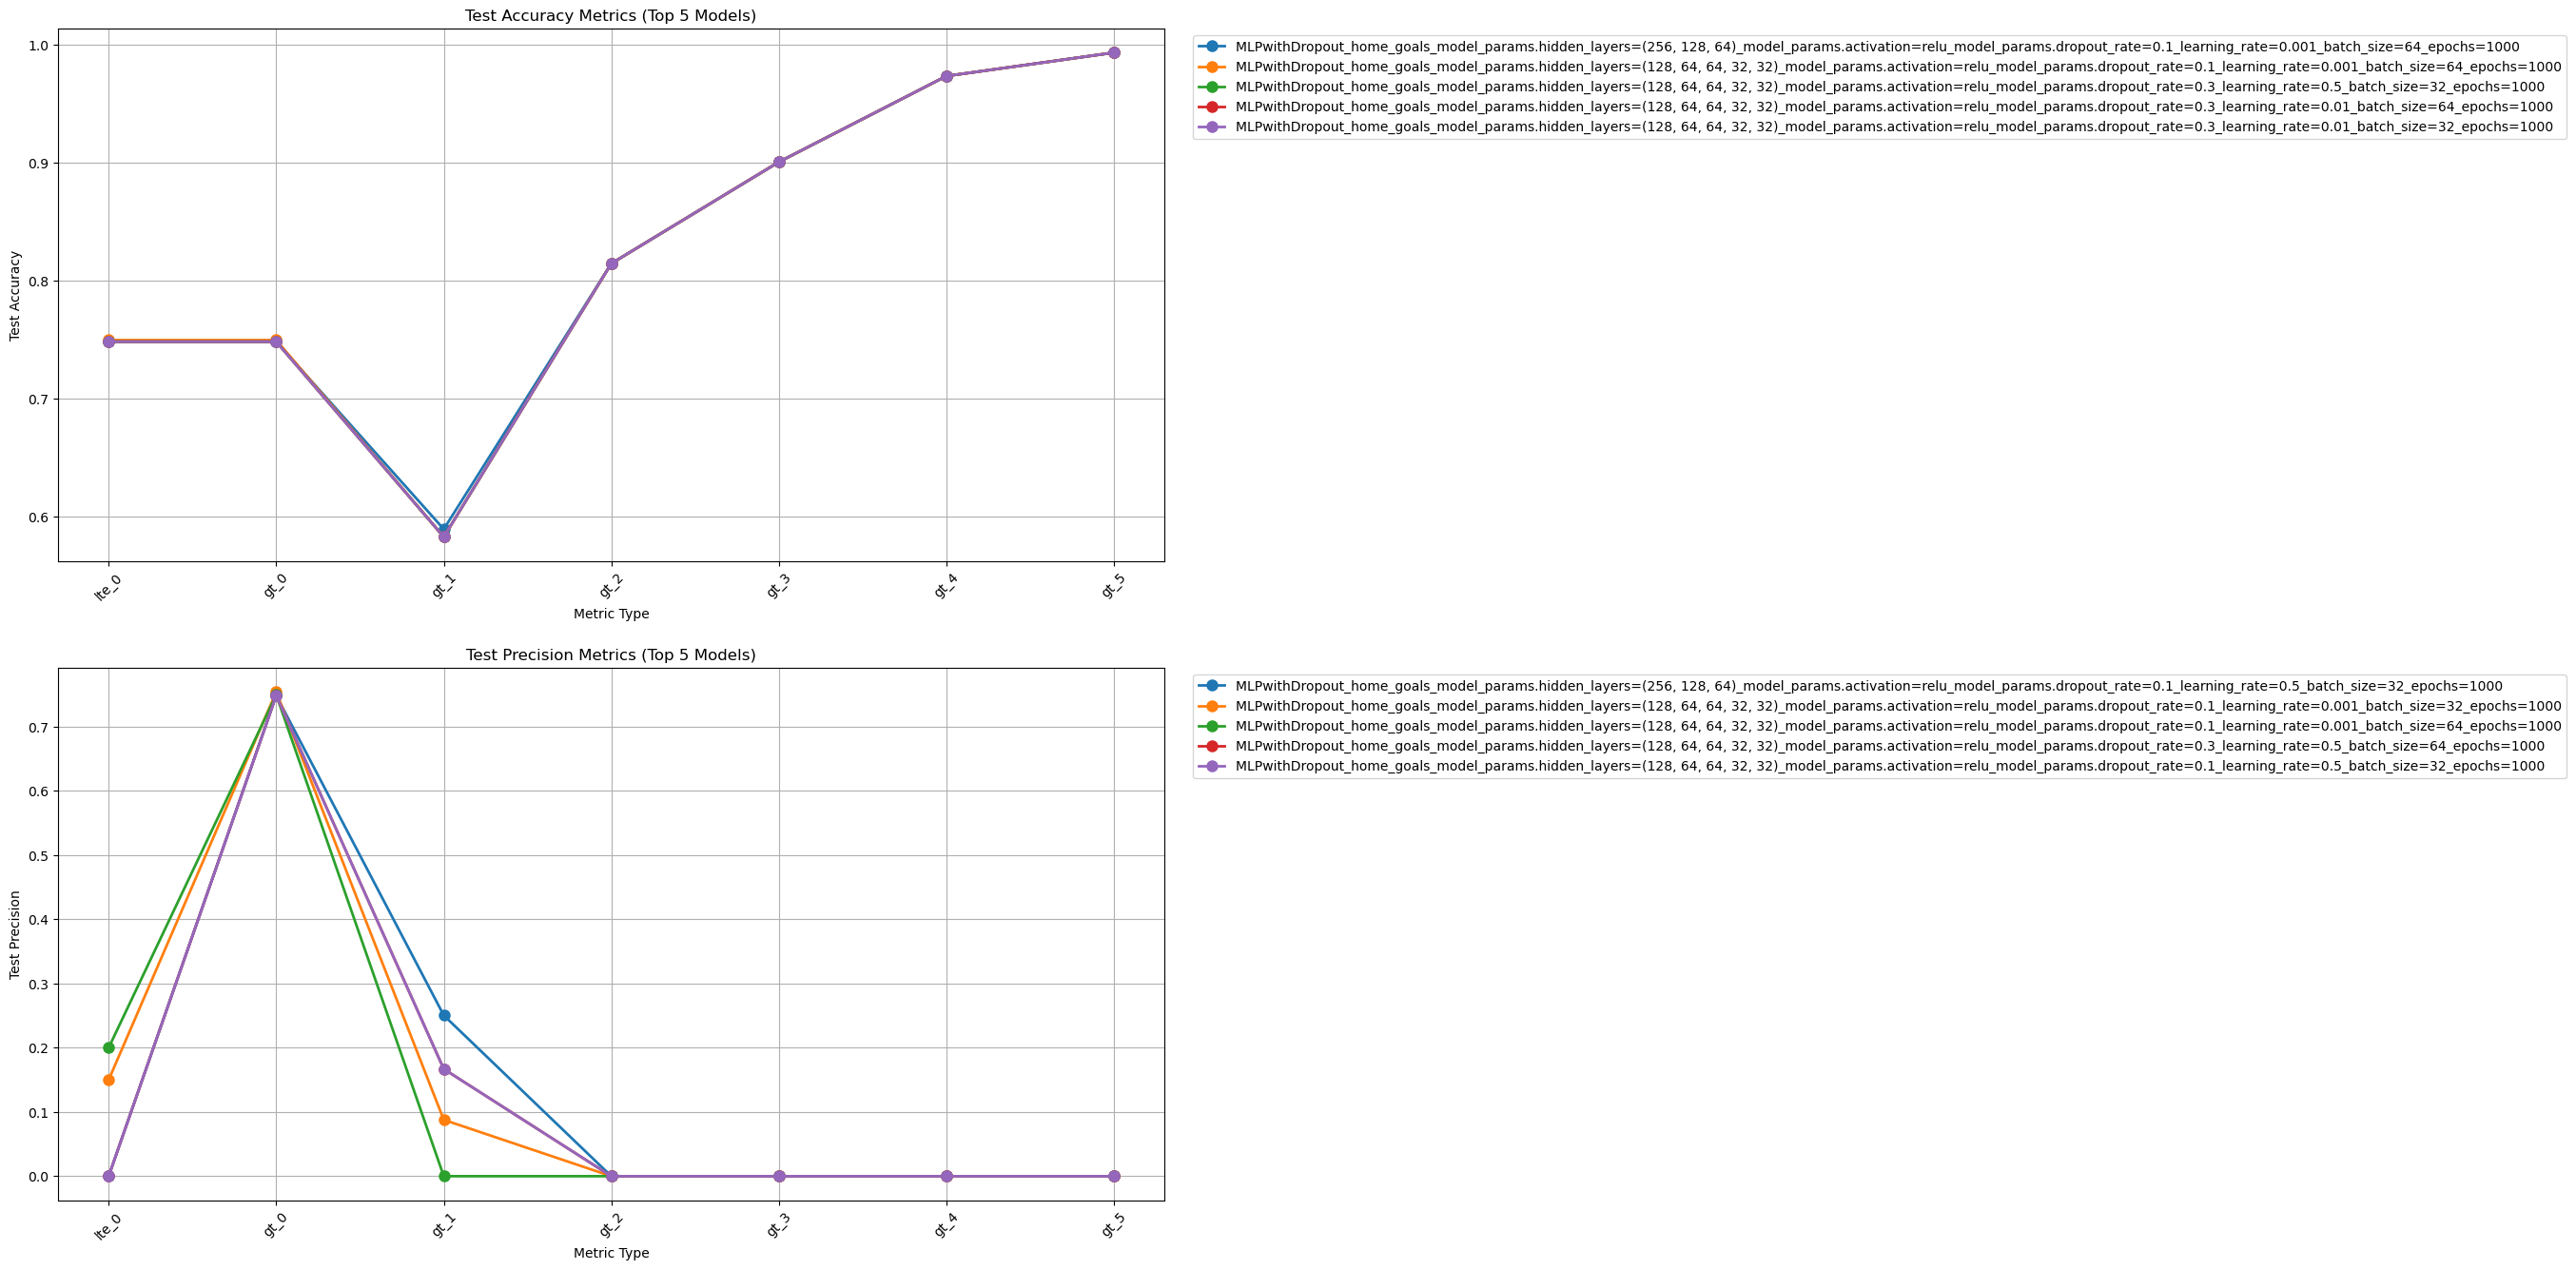

In [10]:
plot_metrics_for_target_and_model(
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    target_col="home_goals",
    model_name="MLPwithDropout",
    tracking_uri=f"{REPO_PATH}/mlflow"
)

[('metrics.home_goals_train_lte_0_accuracy', 0.7665479101221012)] [('metrics.home_goals_train_gt_0_accuracy', 0.7665479101221012), ('metrics.home_goals_train_gt_1_accuracy', 0.5666829844369807), ('metrics.home_goals_train_gt_2_accuracy', 0.7961721291680683), ('metrics.home_goals_train_gt_3_accuracy', 0.9172370152100097), ('metrics.home_goals_train_gt_4_accuracy', 0.9716586865640282), ('metrics.home_goals_train_gt_5_accuracy', 0.9876081727078052)]
['lte_0', 'gt_0', 'gt_1', 'gt_2', 'gt_3', 'gt_4', 'gt_5']
[('metrics.home_goals_train_lte_0_precision', 0.0)] [('metrics.home_goals_train_gt_0_precision', 0.7665479101221012), ('metrics.home_goals_train_gt_1_precision', 0.0), ('metrics.home_goals_train_gt_2_precision', 0.0), ('metrics.home_goals_train_gt_3_precision', 0.0), ('metrics.home_goals_train_gt_4_precision', 0.0), ('metrics.home_goals_train_gt_5_precision', 0.0)]
['lte_0', 'gt_0', 'gt_1', 'gt_2', 'gt_3', 'gt_4', 'gt_5']


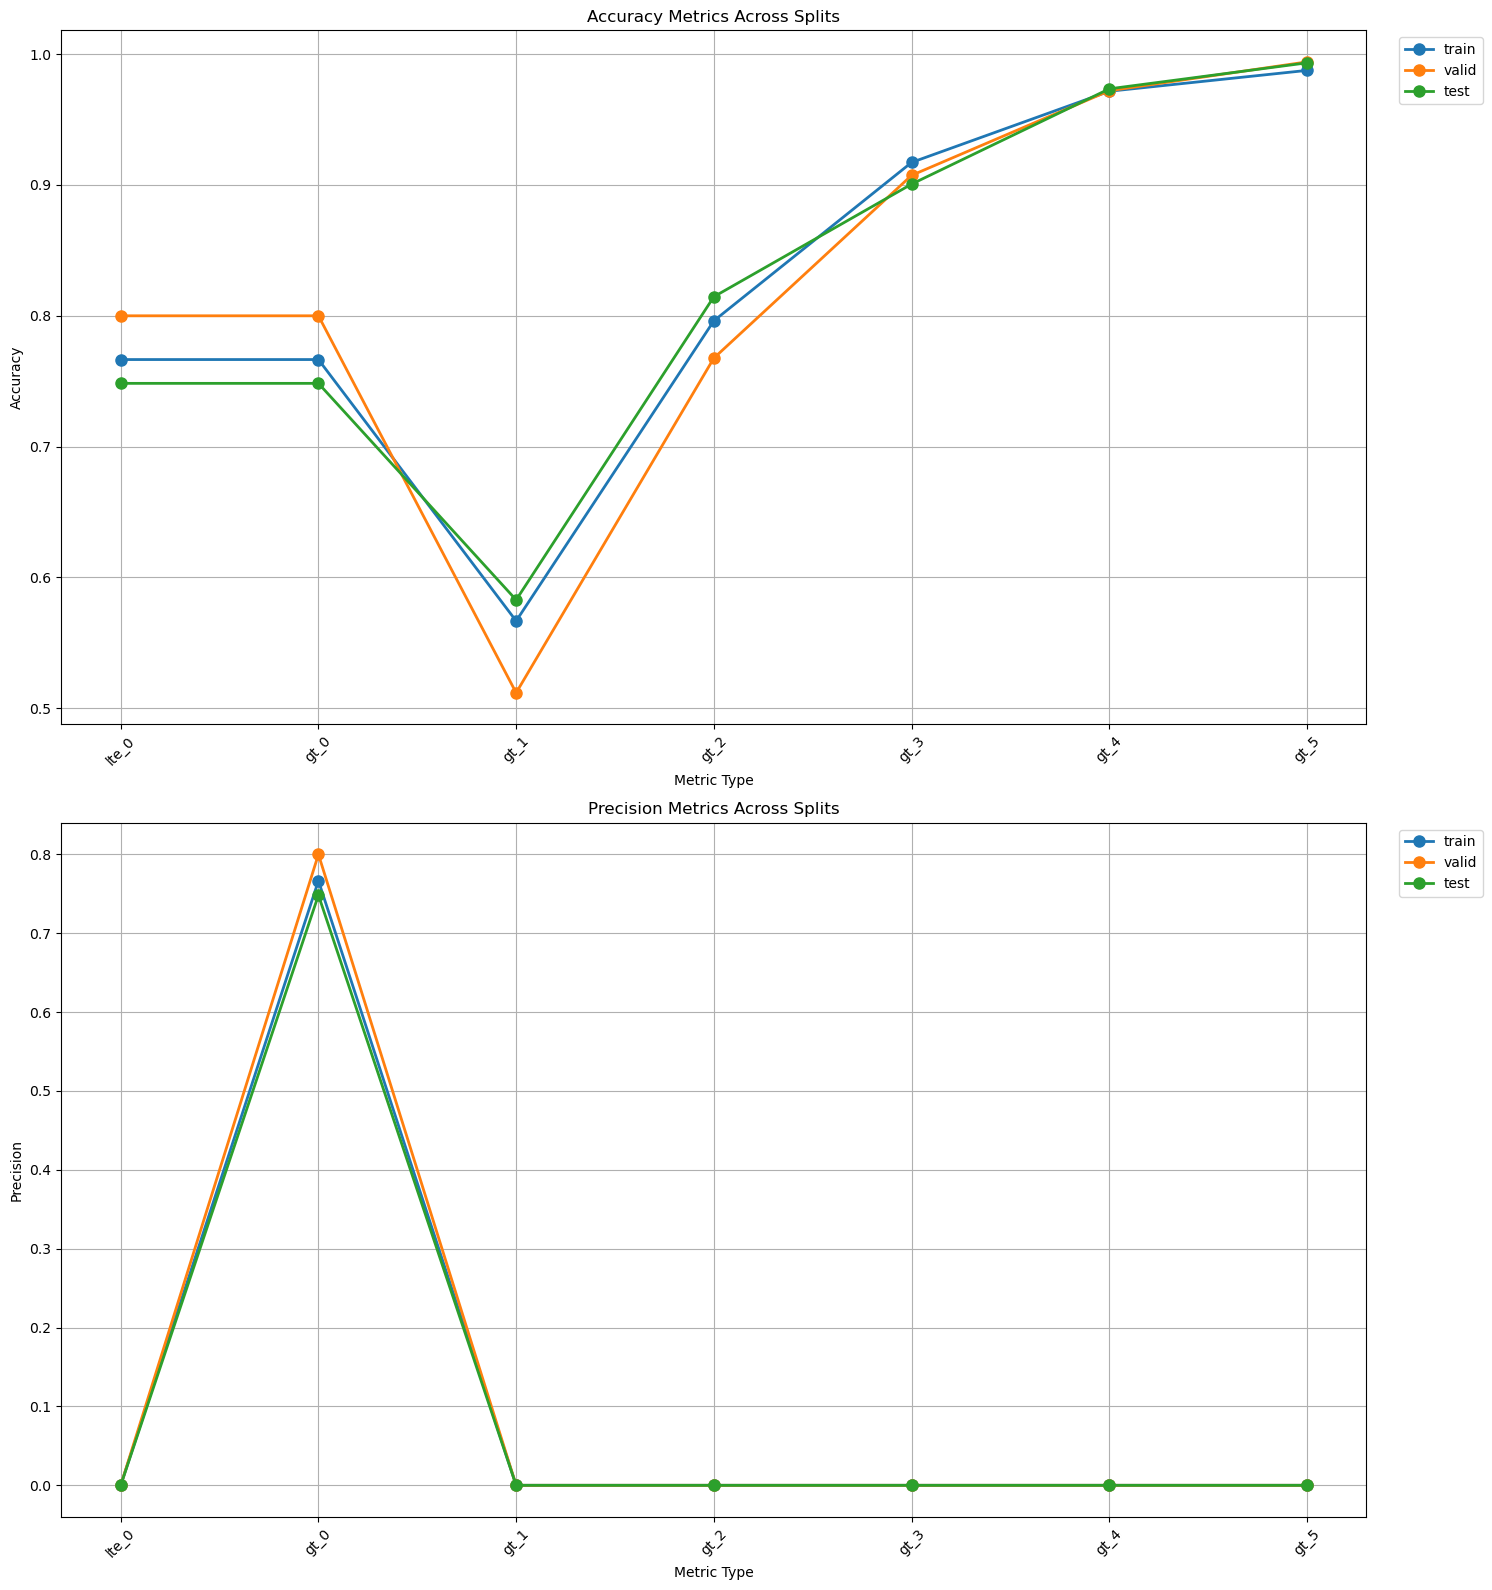

In [11]:
plot_run_metrics_by_split(experiment_name=TRAINGING_CONFIG['experiment_name'],
                         run_name="MLPwithDropout_home_goals_model_params.hidden_layers=(128, 64, 32)_model_params.activation=relu_model_params.dropout_rate=0.5_learning_rate=0.01_batch_size=64_epochs=1000",
                         target_col="home_goals",
                         tracking_uri=f"{REPO_PATH}/mlflow")